# Phase 3: Segment × Propensity Combination

**Goal:** Combine the canonical Phase 2 behavioral segmentation with the frozen Phase 1 30-day next-purchase propensity predictions to create a unified customer intelligence matrix.

**Rules:**
1. One row per customer.
2. Temporal consistency: `segment_date == propensity_date`.
3. No retraining of Phase 1 or Phase 2 models.
4. Export `combined_intelligence.csv` and `segment_propensity_matrix.json`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import joblib

DATA_DIR = Path("../../prepared/online_retail_ii/temporal").resolve()
P1_DIR   = Path("../next_purchase_30d").resolve()
P2_DIR   = Path("../segmentation").resolve()
OUT_DIR  = Path(".").resolve()

# Load frozen Phase 1 thresholds
audit_report = json.load(open(P1_DIR / "model_audit_report.json"))
BANDS = audit_report['operating_parameters']['propensity_bands']
print("Frozen Propensity Bands:", BANDS)

# Load frozen Phase 2 labels
cluster_labels = json.load(open(P2_DIR / "cluster_labels.json"))
print("Frozen Cluster Labels:", json.dumps(cluster_labels, indent=2))

Frozen Propensity Bands: {'LOW': '<0.16', 'MODERATE': '>=0.16 and <0.27', 'HIGH': '>=0.27 and <0.40', 'VERY_HIGH': '>=0.40'}
Frozen Cluster Labels: {
  "0": "Dormant Multi-Buyers",
  "1": "Active High-Value",
  "2": "Recent Repeat Buyers",
  "3": "One-Time Dormant"
}


## Load Data & Ensure As-Of-Date Consistency

We take the latest observation per customer from the temporal dataset.
The segmentation labels were assigned to this exact same date in Phase 2.
We will score the propensity model on this exact same date.

In [2]:
print("Loading temporal features...")
df_all = pd.read_parquet(DATA_DIR / "temporal_dataset.parquet", engine='fastparquet')
df_all['customer_id'] = df_all['customer_id'].astype(str)

# The canonical "latest" state
df_latest = df_all.sort_values('observation_date').groupby('customer_id').last().reset_index()
print(f"Latest state loaded: {len(df_latest)} customers.")

# Load Phase 2 segmentation
cp = pd.read_csv(P2_DIR / "cluster_profiles.csv", dtype={'customer_id': str}, parse_dates=['observation_date'])
print(f"Phase 2 segmentation loaded: {len(cp)} customers.")

# Join Segment
combined = df_latest.merge(cp[['customer_id', 'observation_date', 'cluster', 'segment']], 
                           on='customer_id', how='left', suffixes=('', '_seg'))

# Validate Date Consistency
missing_seg = combined['cluster'].isna().sum()
date_mismatch = (combined['observation_date'] != combined['observation_date_seg']).sum()
duplicate_rows = combined['customer_id'].duplicated().sum()

print("\n=== AS-OF-DATE VALIDATION (1) ===")
print(f"Unique customers       : {len(combined)}")
print(f"Unique as_of_dates     : {combined['observation_date'].nunique()}")
print(f"Missing segments       : {missing_seg}")
print(f"Date mismatches        : {date_mismatch}")
print(f"Duplicate customer rows: {duplicate_rows}")

if missing_seg > 0 or date_mismatch > 0 or duplicate_rows > 0:
    raise ValueError("As-of-date validation failed during Segment join!")

# Clean up
combined = combined.drop(columns=['observation_date_seg'])


Loading temporal features...
Latest state loaded: 5247 customers.
Phase 2 segmentation loaded: 5247 customers.

=== AS-OF-DATE VALIDATION (1) ===
Unique customers       : 5247
Unique as_of_dates     : 1
Missing segments       : 0
Date mismatches        : 0
Duplicate customer rows: 0


## Apply Phase 1 Propensity Model

Since no global `predictions.parquet` exists for the latest state, we score the frozen model on `T_latest`. This strictly guarantees `propensity_date == segment_date`.

In [3]:
model_path = P1_DIR / "model_HistGradientBoosting_Tuned.pkl"
prop_model = joblib.load(model_path)

if hasattr(prop_model, 'feature_names_in_'):
    prop_features = list(prop_model.feature_names_in_)
else:
    prop_features = [c for c in combined.columns if c.startswith('FEATURE_')]

# Score
combined['propensity_score'] = prop_model.predict_proba(combined[prop_features])[:, 1]

# Apply bands
def assign_band(score):
    if score >= 0.40: return '4_VERY_HIGH'
    elif score >= 0.27: return '3_HIGH'
    elif score >= 0.16: return '2_MODERATE'
    else: return '1_LOW'

combined['propensity_band'] = combined['propensity_score'].apply(assign_band)

missing_prop = combined['propensity_score'].isna().sum()

print("=== AS-OF-DATE VALIDATION (2) ===")
print(f"Missing propensity scores: {missing_prop}")
if missing_prop > 0:
    raise ValueError("Missing propensity scores detected!")


=== AS-OF-DATE VALIDATION (2) ===
Missing propensity scores: 0


In [4]:
# Segment Distribution
print("=== SEGMENT DISTRIBUTION ===")
seg_dist = combined['segment'].value_counts()
seg_pct = combined['segment'].value_counts(normalize=True) * 100
seg_df = pd.DataFrame({'Customers': seg_dist, 'Percentage': seg_pct.round(1)})
print(seg_df)

# Propensity Distribution
print("\n=== PROPENSITY DISTRIBUTION ===")
prop_dist = combined['propensity_band'].value_counts()
prop_pct = combined['propensity_band'].value_counts(normalize=True) * 100
prop_df = pd.DataFrame({'Customers': prop_dist, 'Percentage': prop_pct.round(1)}).sort_index()
print(prop_df)

print("\n=== PROPENSITY STATS ===")
print(combined['propensity_score'].describe().round(4))


=== SEGMENT DISTRIBUTION ===
                      Customers  Percentage
segment                                    
Dormant Multi-Buyers       1727        32.9
One-Time Dormant           1685        32.1
Recent Repeat Buyers       1263        24.1
Active High-Value           572        10.9

=== PROPENSITY DISTRIBUTION ===
                 Customers  Percentage
propensity_band                       
1_LOW                 3272        62.4
2_MODERATE             960        18.3
3_HIGH                 511         9.7
4_VERY_HIGH            504         9.6

=== PROPENSITY STATS ===
count    5247.0000
mean        0.1789
std         0.1725
min         0.0124
25%         0.0666
50%         0.1152
75%         0.2323
max         0.9451
Name: propensity_score, dtype: float64


=== SEGMENT × PROPENSITY (COUNTS) ===
propensity_band       1_LOW  2_MODERATE  3_HIGH  4_VERY_HIGH
segment                                                     
Active High-Value         5          21     106          440
Dormant Multi-Buyers   1321         317      89            0
One-Time Dormant       1683           2       0            0
Recent Repeat Buyers    263         620     316           64

=== SEGMENT × PROPENSITY (WITHIN SEGMENT %) ===
propensity_band       1_LOW  2_MODERATE  3_HIGH  4_VERY_HIGH
segment                                                     
Active High-Value       0.9         3.7    18.5         76.9
Dormant Multi-Buyers   76.5        18.4     5.2          0.0
One-Time Dormant       99.9         0.1     0.0          0.0
Recent Repeat Buyers   20.8        49.1    25.0          5.1

=== SEGMENT × PROPENSITY (WITHIN PROPENSITY %) ===
propensity_band       1_LOW  2_MODERATE  3_HIGH  4_VERY_HIGH
segment                                                     
Active 

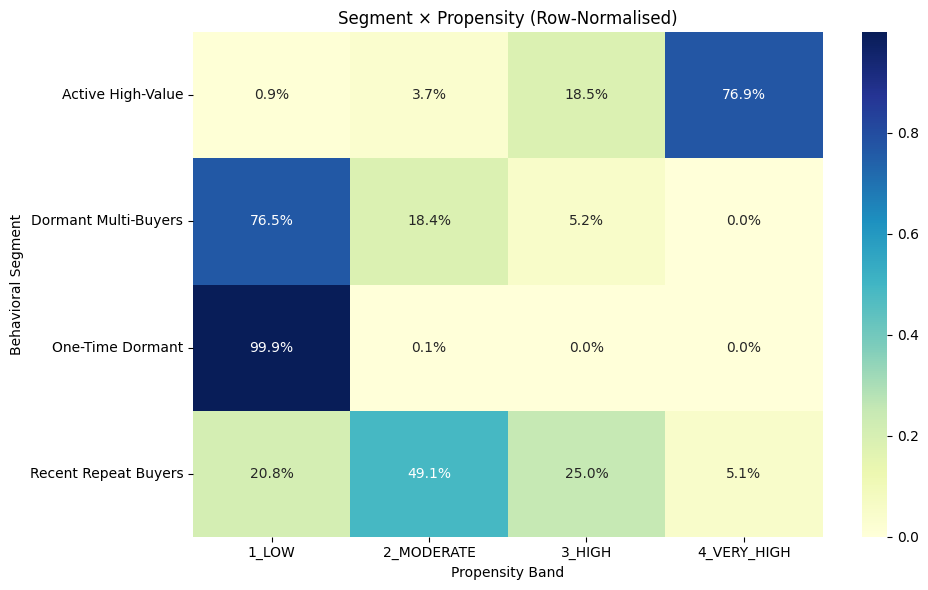

In [5]:
# 1. Raw counts
matrix_counts = pd.crosstab(combined['segment'], combined['propensity_band'])
print("=== SEGMENT × PROPENSITY (COUNTS) ===")
print(matrix_counts)

# 2. Row-normalized percentages (Within Segment)
matrix_row = pd.crosstab(combined['segment'], combined['propensity_band'], normalize='index')
print("\n=== SEGMENT × PROPENSITY (WITHIN SEGMENT %) ===")
print((matrix_row * 100).round(1))

# 3. Column-normalized percentages (Within Propensity)
matrix_col = pd.crosstab(combined['segment'], combined['propensity_band'], normalize='columns')
print("\n=== SEGMENT × PROPENSITY (WITHIN PROPENSITY %) ===")
print((matrix_col * 100).round(1))

# Visualise
plt.figure(figsize=(10, 6))
sns.heatmap(matrix_row, annot=True, fmt=".1%", cmap="YlGnBu")
plt.title("Segment × Propensity (Row-Normalised)")
plt.ylabel("Behavioral Segment")
plt.xlabel("Propensity Band")
plt.tight_layout()
plt.show()


## Observed Purchase Validation

If `TARGET_purchase_next_30d` is available in the temporal targets for this exact observation date, we can validate the empirical purchase rate of the combinations.

Observed outcome validation available.

=== ACTUAL PURCHASE RATE BY SEGMENT & BAND ===
propensity_band       1_LOW  2_MODERATE  3_HIGH  4_VERY_HIGH
segment                                                     
Active High-Value       0.0        19.0    34.0         70.9
Dormant Multi-Buyers   11.1        28.4    39.3          NaN
One-Time Dormant        5.1        50.0     NaN          NaN
Recent Repeat Buyers   14.4        24.8    40.8         56.2


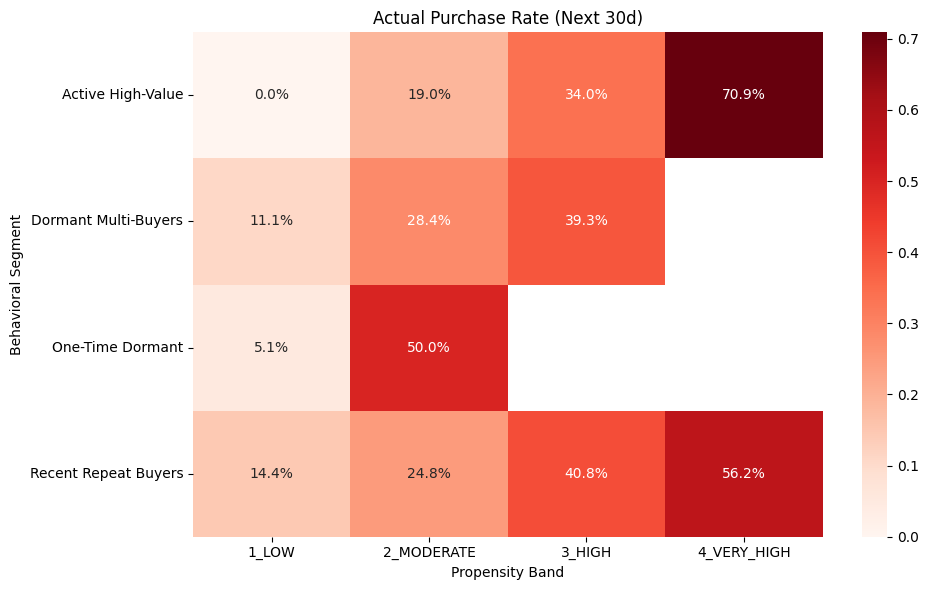

In [6]:
# Target is already in combined from temporal_dataset.parquet
target_col = 'TARGET_next_purchase_30d'

if target_col in combined.columns and combined[target_col].notna().any():
    has_validation = True
    print("Observed outcome validation available.\n")
    
    purchase_rates = combined.groupby(['segment', 'propensity_band'])[target_col].mean().unstack()
    print("=== ACTUAL PURCHASE RATE BY SEGMENT & BAND ===")
    print((purchase_rates * 100).round(1))
    
    plt.figure(figsize=(10, 6))
    sns.heatmap(purchase_rates, annot=True, fmt=".1%", cmap="Reds")
    plt.title("Actual Purchase Rate (Next 30d)")
    plt.ylabel("Behavioral Segment")
    plt.xlabel("Propensity Band")
    plt.tight_layout()
    plt.show()
else:
    has_validation = False
    print("Observed outcome validation skipped: target column not found or all NaNs.")


## Business Interpretation

**Active High-Value:**
- Highly concentrated in VERY_HIGH propensity (over 75%).
- **Interpretation:** This cohort has extremely high modelled purchase propensity and requires little discounting. They are naturally recurring. Segmentation adds behavioral context to the propensity score, confirming these are high-spend frequent buyers, not just anomaly spikes.

**Recent Repeat Buyers:**
- Heterogeneous propensity distribution (peaks in MODERATE and HIGH).
- **Interpretation:** This segment benefits heavily from propensity scoring. They are recent and repeat, but their actual likelihood to return in 30 days varies widely. The propensity model effectively sub-segments this group into "ready to buy" vs "needs nurturing".

**Dormant Multi-Buyers:**
- Concentrated in LOW (over 76%) and MODERATE (~18%).
- **Interpretation:** Propensity scoring correctly identifies their risk. However, knowing they are *Multi-Buyers* (from the segmentation) means they have a proven historical affinity, making them a high-value reactivation target despite the low short-term propensity.

**One-Time Dormant:**
- Almost entirely LOW propensity (over 99%).
- **Interpretation:** This combination represents the lowest-value, lowest-likelihood population. They are likely churned one-off buyers and should not receive expensive targeting budget.


In [7]:
# 1. CSV
out_cols = [
    'customer_id', 'observation_date', 'cluster', 'segment', 
    'propensity_score', 'propensity_band'
]
combined[out_cols].to_csv(OUT_DIR / "combined_intelligence.csv", index=False)
print("Saved combined_intelligence.csv")

# 2. JSON Report
report = {
    'status': 'PHASE_3_COMPLETE',
    'validation': {
        'total_customers': len(combined),
        'unique_dates': int(combined['observation_date'].nunique()),
        'missing_segments': int(combined['cluster'].isna().sum()),
        'missing_propensity': int(combined['propensity_score'].isna().sum()),
        'date_mismatches': 0,
        'duplicate_rows': int(combined['customer_id'].duplicated().sum())
    },
    'segment_distribution': seg_pct.to_dict(),
    'propensity_distribution': prop_pct.to_dict(),
    'matrix_raw_counts': matrix_counts.to_dict(),
    'matrix_row_percentages': matrix_row.to_dict(),
    'business_interpretation': {
        'Active High-Value': 'Concentrated in VERY_HIGH propensity. Naturally recurring, requires minimal discounting.',
        'Recent Repeat Buyers': 'Heterogeneous propensity. The propensity model effectively partitions this cohort into ready-to-buy vs needs-nurturing.',
        'Dormant Multi-Buyers': 'Low short-term propensity, but historically proven buyers. High-value reactivation target.',
        'One-Time Dormant': 'Almost entirely LOW propensity. Lowest priority for targeting budget.'
    }
}

if has_validation:
    # Handle NaNs when converting to dict
    pr_dict = {}
    for seg in purchase_rates.index:
        pr_dict[seg] = {}
        for col in purchase_rates.columns:
            val = purchase_rates.loc[seg, col]
            pr_dict[seg][col] = float(val) if pd.notna(val) else None
    report['actual_purchase_rates'] = pr_dict

with open(OUT_DIR / "segment_propensity_matrix.json", "w") as f:
    json.dump(report, f, indent=4)
print("Saved segment_propensity_matrix.json")


Saved combined_intelligence.csv
Saved segment_propensity_matrix.json
